# Lab 4-4: 지도학습 도전과제 극복을 위한 핵심 테크닉 실습

본 실습에서는 Lab 4-3에서 체감한 머신러닝/딥러닝의 **도전과제(Challenging Problems)**를 극복하기 위한 대표적인 해결 기법들을 직접 구현하고 검증합니다.

---

### [학습 목표]
1. **기울기 소실 극복 (Residual Connection)**: 커스텀 `ResidualBlock` 레이어를 구현하고, 깊은 Plain 망과 ResNet 구조의 학습 성능 차이를 비교합니다.
2. **과적합 극복 (L1 / L2 가중치 규제)**: 모델 가중치에 패널티를 부여하는 L1, L2, ElasticNet(L1+L2) 정규화를 적용하여 검증 손실(Val Loss) 안정화를 확인합니다.
3. **과적합 극복 (Dropout & Early Stopping)**: 학습 중 무작위로 뉴런을 비활성화하는 `Dropout`을 적용하고 과적합 억제 효과를 관찰합니다.
4. **클래스 불균형 극복 (Class Weighting & Data Augmentation)**: 소수 클래스에 가중치를 부여하는 `class_weight`와 소수 클래스만을 증강하는 `Balanced Data Augmentation`을 적용하여 소수 클래스 검출 성능(Recall/F1-Score)을 개선합니다.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

tf.random.set_seed(42)
np.random.seed(42)
print("TensorFlow 버전:", tf.__version__)


TensorFlow 버전: 2.21.0


---
## Part 1. Residual Connection을 통한 Vanishing Gradient 완화 실습

깊은 신경망에서 층을 깊게 쌓을수록 기울기 소실(Vanishing Gradient)이나 성능 저하(Degradation)가 발생합니다.
ResNet의 핵심 아이디어인 **Residual Connection (ResNet)** 은 입력 $x$를 변형 없이 그대로 출력에 더해주는 $F(x) + x$ 지름길(Shortcut)을 제공함으로써 기울기가 손실 없이 초기 층까지 역전파되도록 돕습니다.

- Plain Deep Network (Residual 없음)
- Residual Network (Residual Block 포함)

두 모델을 동일한 데이터셋에서 학습시켜 성능을 비교합니다.


In [2]:
# 1. 데이터 준비
X_res, y_res = make_moons(n_samples=2000, noise=0.2, random_state=42)
X_train_res, X_test_res, y_train_res, y_test_res = train_test_split(X_res, y_res, test_size=0.3, random_state=42)

scaler_res = StandardScaler()
X_train_res = scaler_res.fit_transform(X_train_res)
X_test_res = scaler_res.transform(X_test_res)

print(f"학습 샘플 수: {len(X_train_res)}, 검증 샘플 수: {len(X_test_res)}")


학습 샘플 수: 1400, 검증 샘플 수: 600


### 1-1. Plain Deep Network 정의 (Residual 없음)


In [3]:
def build_deep_plain(layers=20, units=64):
    model = tf.keras.Sequential()
    model.add(tf.keras.layers.Input(shape=(2,)))
    for _ in range(layers):
        model.add(tf.keras.layers.Dense(units, activation="relu"))
    model.add(tf.keras.layers.Dense(1, activation="sigmoid"))
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 1-2. Residual Block 정의 및 Residual Network 정의


In [4]:
class ResidualBlock(tf.keras.layers.Layer):
    def __init__(self, units):
        super().__init__()
        self.dense1 = tf.keras.layers.Dense(units, activation="relu")
        self.dense2 = tf.keras.layers.Dense(units, activation=None)
        self.activation = tf.keras.layers.Activation("relu")

    def call(self, inputs):
        x = self.dense1(inputs)
        x = self.dense2(x)
        # ✅ 정답: skip connection — 변환 결과에 원본 입력을 더한 뒤 활성화
        return self.activation(x + inputs)

def build_residual_network(blocks=10, units=64):
    inputs = tf.keras.Input(shape=(2,))
    x = tf.keras.layers.Dense(units, activation="relu")(inputs)
    for _ in range(blocks):
        # ✅ 정답: ResidualBlock 을 x 에 적용
        x = ResidualBlock(units)(x)
    outputs = tf.keras.layers.Dense(1, activation="sigmoid")(x)
    model = tf.keras.Model(inputs, outputs)
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


> **[TODO 해설] Residual Block 구현에서 주의할 점 2가지**
>
> ```python
> def call(self, inputs):
>     x = self.dense1(inputs)   # Dense + ReLU
>     x = self.dense2(x)        # Dense, 활성화 없음(linear)
>     return self.activation(x + inputs)   # 더한 "뒤에" ReLU
> ```
>
> 1. **두 번째 Dense 는 활성화가 없어야(`activation=None`) 합니다.** 덧셈 *후*에
>    ReLU 를 적용해야 항등 경로(identity path)가 비선형에 훼손되지 않습니다.
> 2. **`x + inputs` 는 차원이 같아야 합니다.** 그래서 `build_residual_network` 에서
>    첫 `Dense(units)` 로 입력 차원을 2 → 64 로 맞춘 뒤 블록을 쌓습니다.
>
> 깊이 비교: Plain 은 Dense 20층, Residual 은 블록당 Dense 2개 × 10블록 + 입력 1개
> = 총 21층으로 **거의 같은 깊이**입니다. 공정한 비교가 됩니다.

### 1-3. 모델 학습 (Plain vs Residual) 및 결과 비교 시각화


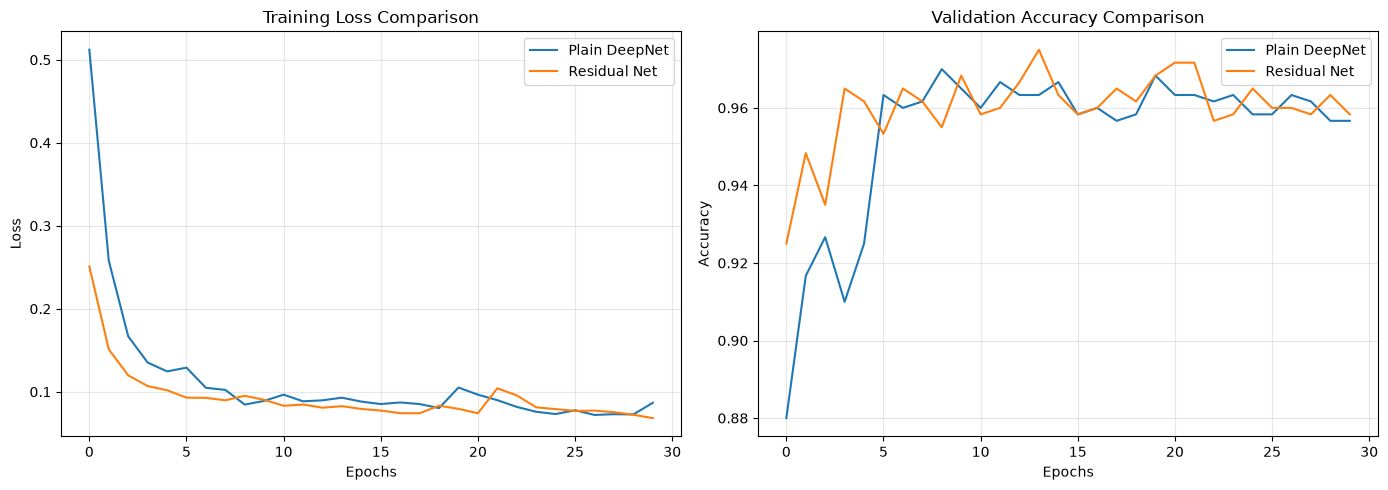

In [5]:
plain_model = build_deep_plain(layers=20, units=64)
history_plain = plain_model.fit(X_train_res, y_train_res, validation_data=(X_test_res, y_test_res),
                                epochs=30, batch_size=32, verbose=0)

res_model = build_residual_network(blocks=10, units=64)
history_res = res_model.fit(X_train_res, y_train_res, validation_data=(X_test_res, y_test_res),
                            epochs=30, batch_size=32, verbose=0)

plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_plain.history["loss"], label="Plain DeepNet")
plt.plot(history_res.history["loss"], label="Residual Net")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_plain.history["val_accuracy"], label="Plain DeepNet")
plt.plot(history_res.history["val_accuracy"], label="Residual Net")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


---
## Part 2. L1, L2 Regularization 실습

이번 파트에서는 **L1, L2 Regularization** 이 Overfitting 완화에 어떻게 도움이 되는지 체감해봅니다.

- 작은 데이터셋과 복잡한 모델로 Overfitting 유도
- Regularization 유무 비교 (No Regularization, L1, L2, L1+L2)
- Validation Loss/Accuracy 곡선으로 비교


In [6]:
# 1. 데이터 준비 (작은 데이터셋 -> Overfitting 유도)
X_reg, y_reg = make_moons(n_samples=100, noise=0.25, random_state=42)
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.3, random_state=42)

scaler_reg = StandardScaler()
X_train_reg = scaler_reg.fit_transform(X_train_reg)
X_test_reg = scaler_reg.transform(X_test_reg)


### 2-1. 모델 생성 함수 (Regularization 적용 가능)


In [7]:
def build_model(regularizer=None):
    # ✅ 정답: 모든 Dense 에 kernel_regularizer=regularizer 적용
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(128, activation="relu", kernel_regularizer=regularizer),
        tf.keras.layers.Dense(1, activation="sigmoid", kernel_regularizer=regularizer)
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 2-2. Regularization 설정 및 모델 학습


In [8]:
models = {
    "No Regularization": build_model(),
    "L1 (0.001)": build_model(tf.keras.regularizers.l1(0.001)),
    "L2 (0.001)": build_model(tf.keras.regularizers.l2(0.001)),
    "L1+L2 (0.001)": build_model(tf.keras.regularizers.l1_l2(l1=0.001, l2=0.001))
}

histories = {}

for name, model in models.items():
    print(f"Training: {name}")
    history = model.fit(
        X_train_reg, y_train_reg,
        validation_data=(X_test_reg, y_test_reg),
        epochs=200,
        batch_size=16,
        verbose=0
    )
    histories[name] = history


Training: No Regularization
Training: L1 (0.001)
Training: L2 (0.001)
Training: L1+L2 (0.001)


### 2-3. 결과 시각화 (Loss & Accuracy)


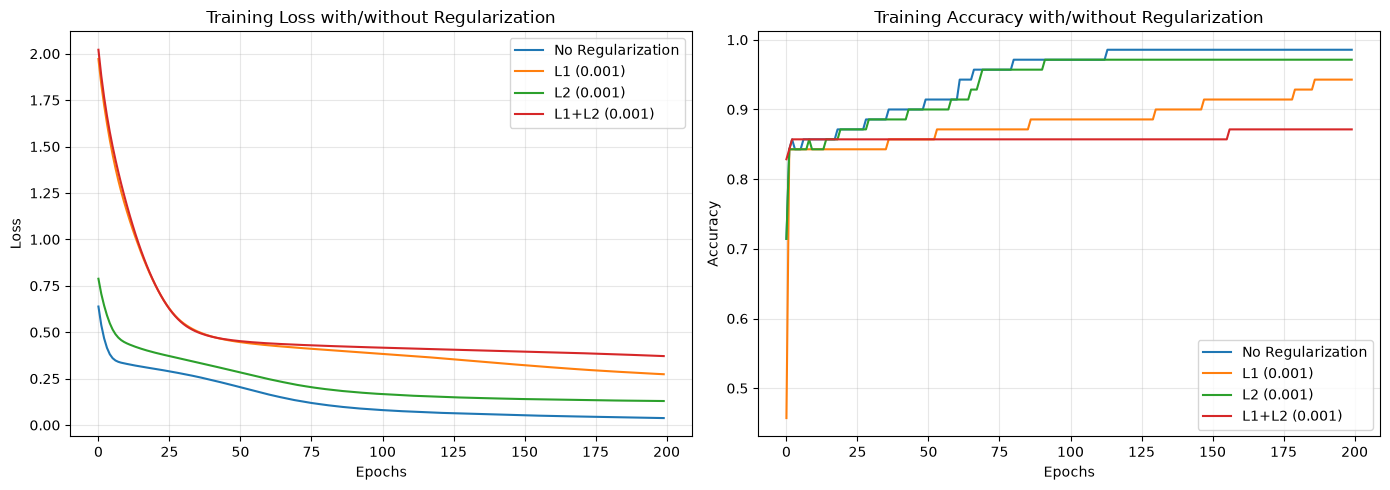

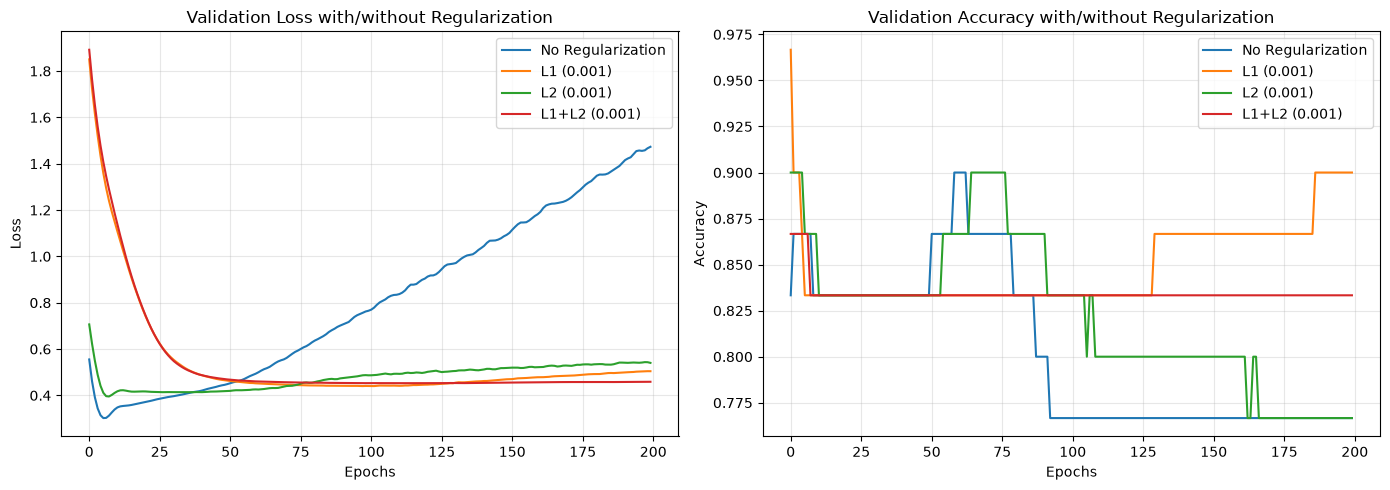

In [9]:
# 1. Training Loss & Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["loss"], label=f"{name}")
plt.title("Training Loss with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["accuracy"], label=f"{name}")
plt.title("Training Accuracy with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Validation Loss & Accuracy
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
for name, history in histories.items():
    plt.plot(history.history["val_loss"], label=f"{name}")
plt.title("Validation Loss with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
for name, history in histories.items():
    plt.plot(history.history["val_accuracy"], label=f"{name}")
plt.title("Validation Accuracy with/without Regularization")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 3. Dropout 실습

이번 파트에서는 **Dropout** 이 Overfitting 완화에 어떻게 도움이 되는지 체감해봅니다.

- 작은 데이터셋과 복잡한 모델로 Overfitting 유도
- Dropout 유무 비교
- Validation Loss/Accuracy 곡선으로 비교


In [10]:
# 1. 데이터 준비 (작은 데이터셋 -> Overfitting 유도)
# (Part 2와 동일한 100개 make_moons 데이터 사용)
print(f"X_train shape: {X_train_reg.shape}, X_test shape: {X_test_reg.shape}")


X_train shape: (70, 2), X_test shape: (30, 2)


### 3-1. Dropout 없는 모델과 Dropout 적용 모델 정의


In [11]:
def build_model_with_dropout():
    # ✅ 정답: Dense 사이에 Dropout(0.5) 삽입
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.5),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model

def build_model_without_dropout():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(2,)),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 3-2. 모델 학습 (Dropout 유무 비교) 및 결과 시각화


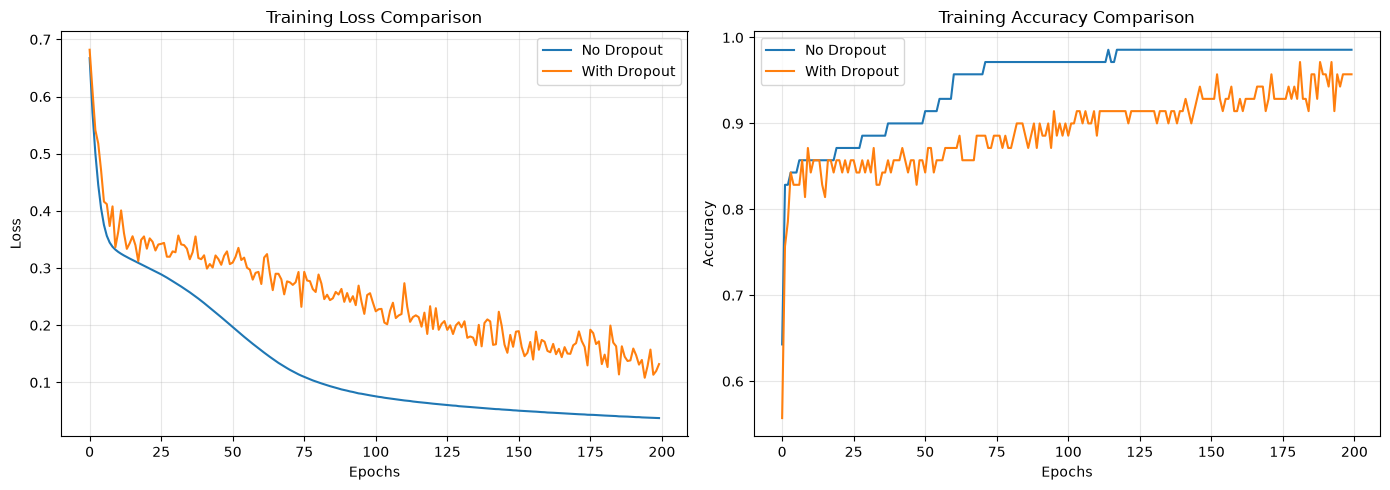

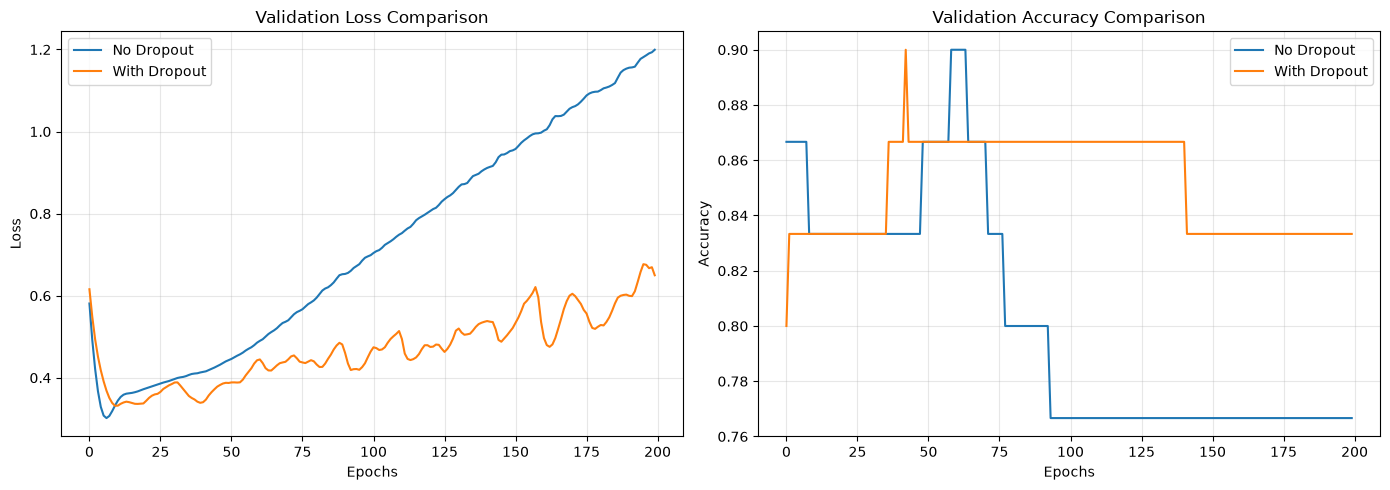

In [12]:
model_no_dropout = build_model_without_dropout()
model_with_dropout = build_model_with_dropout()

history_no_dropout = model_no_dropout.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_test_reg, y_test_reg),
    epochs=200, batch_size=16, verbose=0
)

history_with_dropout = model_with_dropout.fit(
    X_train_reg, y_train_reg,
    validation_data=(X_test_reg, y_test_reg),
    epochs=200, batch_size=16, verbose=0
)

# 1. Training Loss & Accuracy 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history["loss"], label="No Dropout")
plt.plot(history_with_dropout.history["loss"], label="With Dropout")
plt.title("Training Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history["accuracy"], label="No Dropout")
plt.plot(history_with_dropout.history["accuracy"], label="With Dropout")
plt.title("Training Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Validation Loss & Accuracy 비교
plt.figure(figsize=(14, 5))

plt.subplot(1, 2, 1)
plt.plot(history_no_dropout.history["val_loss"], label="No Dropout")
plt.plot(history_with_dropout.history["val_loss"], label="With Dropout")
plt.title("Validation Loss Comparison")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)

plt.subplot(1, 2, 2)
plt.plot(history_no_dropout.history["val_accuracy"], label="No Dropout")
plt.plot(history_with_dropout.history["val_accuracy"], label="With Dropout")
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## Part 4. Balanced Data Augmentation & Class Weighting 실습

이번 실습에서는 **Class Imbalance 문제**를 다루는 두 가지 방법을 비교합니다.

- Baseline (불균형 데이터 그대로 학습)
- Balanced Data Augmentation (소수 클래스만 증강)
- Class Weighting (소수 클래스에 가중치 부여)

CIFAR-10 (Cat vs Dog) 데이터셋으로 실험합니다.


### 4-1. 데이터 준비 (CIFAR-10: Cat vs Dog, 불균형 만들기)


In [13]:
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train, y_test = y_train.flatten(), y_test.flatten()

# 클래스 3=Cat, 5=Dog
mask_train = (y_train == 3) | (y_train == 5)  # 3=Cat, 5=Dog
mask_test = (y_test == 3) | (y_test == 5)
X_train, y_train = X_train[mask_train], y_train[mask_train]
X_test, y_test = X_test[mask_test], y_test[mask_test]

# 라벨 재정의: Cat=0, Dog=1
y_train = (y_train == 5).astype(int)
y_test = (y_test == 5).astype(int)

# Cat 샘플 줄여서 불균형 만들기
# cat data를 20%만 사용
cat_idx = np.where(y_train == 0)[0]
dog_idx = np.where(y_train == 1)[0]
np.random.seed(42)
cat_idx_reduced = np.random.choice(cat_idx, size=len(cat_idx)//5, replace=False)
imbalanced_idx = np.concatenate([cat_idx_reduced, dog_idx])
X_train, y_train = X_train[imbalanced_idx], y_train[imbalanced_idx]

X_train = X_train.astype("float32")/255.0
X_test = X_test.astype("float32")/255.0

print("Train class distribution (imbalanced):", np.bincount(y_train))


A local file was found, but it seems to be incomplete or outdated because the auto file hash does not match the original value of 6d958be074577803d12ecdefd02955f39262c83c16fe9348329d7fe0b5c001ce so we will re-download the data.
170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 2540s 15us/step
Train class distribution (imbalanced): [1000 5000]


### 4-2. CNN 모델 정의


In [14]:
def build_model():
    model = tf.keras.Sequential([
        tf.keras.layers.InputLayer(shape=(32,32,3)),
        tf.keras.layers.Conv2D(32, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
        tf.keras.layers.MaxPooling2D((2,2)),
        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(1, activation="sigmoid")
    ])
    model.compile(optimizer="adam", loss="binary_crossentropy", metrics=["accuracy"])
    return model


### 4-3. Balanced Data Augmentation (소수 클래스만 증강)


In [15]:
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

cat_imgs = X_train[y_train==0]
dog_imgs = X_train[y_train==1]
cat_labels = y_train[y_train==0]
dog_labels = y_train[y_train==1]

# ✅ 정답: 다수 클래스(Dog)와 소수 클래스(Cat)의 개수 차이
needed = len(dog_labels) - len(cat_labels)
print("부족한 소수 클래스(Cat) 샘플 수:", needed)
augmented_cats, augmented_labels = [], []

# 소수 클래스(Cat)만 증강
for X_batch, y_batch in datagen.flow(cat_imgs, cat_labels, batch_size=32, seed=42):
    augmented_cats.append(X_batch)
    augmented_labels.append(y_batch)
    if len(np.concatenate(augmented_labels)) >= needed:
        break

augmented_cats = np.concatenate(augmented_cats)[:needed]
augmented_labels = np.concatenate(augmented_labels)[:needed]

# ✅ 정답: 원본 + 증강분 결합
X_balanced = np.concatenate([X_train, augmented_cats])
y_balanced = np.concatenate([y_train, augmented_labels])

print("Balanced train class distribution:", np.bincount(y_balanced))


부족한 소수 클래스(Cat) 샘플 수: 4000
Balanced train class distribution: [5000 5000]


### 4-4. Class Weighting 설정


In [16]:
# ✅ 정답: w_k = n_samples / (n_classes * n_samples_k) — 적은 클래스일수록 큰 가중치
class_weights = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weights = dict(enumerate(class_weights))
print("Class Weights:", class_weights)


Class Weights: {0: np.float64(3.0), 1: np.float64(0.6)}


### 4-5. 학습 (Baseline vs Balanced Augmentation vs Class Weighting)


In [17]:
histories_cifar = {}

# 1. Baseline
print("1. Baseline 학습 중...")
model_base = build_model()
histories_cifar["Baseline"] = model_base.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, verbose=0
)

# 2. Balanced Data Augmentation
print("2. Balanced Data Augmentation 학습 중...")
model_aug = build_model()
histories_cifar["Balanced Augmentation"] = model_aug.fit(
    X_balanced, y_balanced, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, verbose=0
)

# 3. Class Weighting
print("3. Class Weighting 학습 중...")
model_weighted = build_model()
histories_cifar["Class Weighting"] = model_weighted.fit(
    X_train, y_train, validation_data=(X_test, y_test),
    epochs=5, batch_size=64, class_weight=class_weights, verbose=0
)


1. Baseline 학습 중...
2. Balanced Data Augmentation 학습 중...
3. Class Weighting 학습 중...


### 4-6. 결과 비교 시각화 (Validation Accuracy)


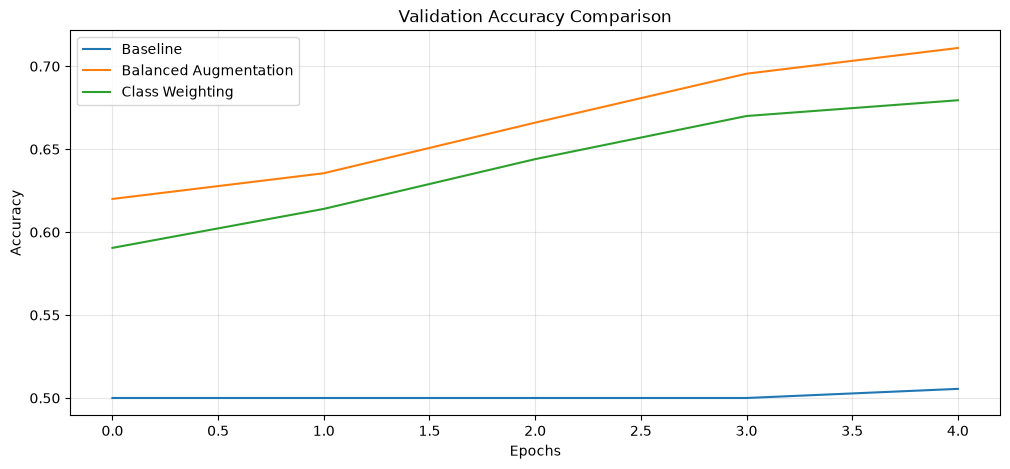

In [18]:
plt.figure(figsize=(12, 5))
for name, history in histories_cifar.items():
    plt.plot(history.history["val_accuracy"], label=name)
plt.title("Validation Accuracy Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()


### 4-7. 모델별 Confusion Matrix 및 Classification Report 비교


Classification Report (Baseline):
              precision    recall  f1-score   support

         Cat     0.8667    0.0130    0.0256      1000
         Dog     0.5028    0.9980    0.6687      1000

    accuracy                         0.5055      2000
   macro avg     0.6847    0.5055    0.3471      2000
weighted avg     0.6847    0.5055    0.3471      2000



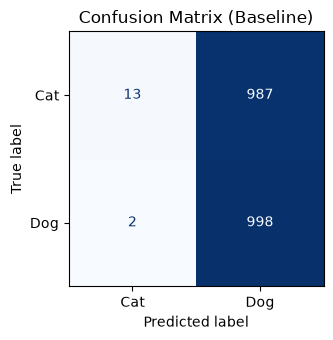

In [19]:
# 1. Baseline 평가
y_pred_base = (model_base.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Baseline):")
print(classification_report(y_test, y_pred_base, digits=4, target_names=["Cat", "Dog"]))

cm_base = confusion_matrix(y_test, y_pred_base)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_base, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Baseline)")
plt.tight_layout()
plt.show()


Classification Report (Augmentation):
              precision    recall  f1-score   support

         Cat     0.6881    0.7720    0.7276      1000
         Dog     0.7403    0.6500    0.6922      1000

    accuracy                         0.7110      2000
   macro avg     0.7142    0.7110    0.7099      2000
weighted avg     0.7142    0.7110    0.7099      2000



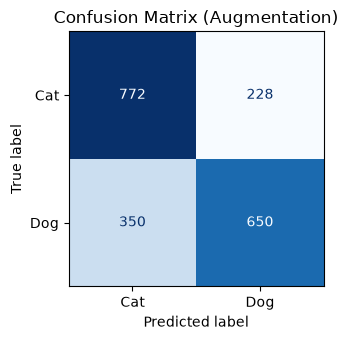

In [20]:
# 2. Balanced Data Augmentation 평가
y_pred_aug = (model_aug.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Augmentation):")
print(classification_report(y_test, y_pred_aug, digits=4, target_names=["Cat", "Dog"]))

cm_aug = confusion_matrix(y_test, y_pred_aug)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_aug, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Augmentation)")
plt.tight_layout()
plt.show()


Classification Report (Class weighting):
              precision    recall  f1-score   support

         Cat     0.6590    0.7440    0.6989      1000
         Dog     0.7061    0.6150    0.6574      1000

    accuracy                         0.6795      2000
   macro avg     0.6825    0.6795    0.6782      2000
weighted avg     0.6825    0.6795    0.6782      2000



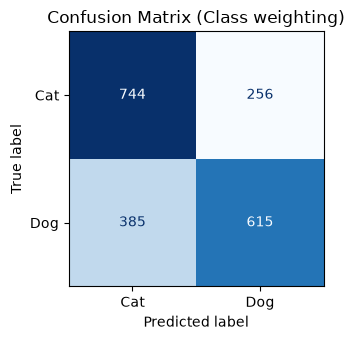

In [21]:
# 3. Class Weighting 평가
y_pred_weighted = (model_weighted.predict(X_test, verbose=0) > 0.5).astype(int).flatten()
print("Classification Report (Class weighting):")
print(classification_report(y_test, y_pred_weighted, digits=4, target_names=["Cat", "Dog"]))

cm_weighted = confusion_matrix(y_test, y_pred_weighted)
fig, ax = plt.subplots(figsize=(4, 3.5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_weighted, display_labels=["Cat", "Dog"])
disp.plot(ax=ax, cmap="Blues", colorbar=False)
plt.title("Confusion Matrix (Class weighting)")
plt.tight_layout()
plt.show()


### 💡 [생각해보기 - 도전과제 종합 정리]
1. ResNet의 Skip Connection은 왜 일반 깊은 망보다 학습 손실을 빠르게 줄이고 깊은 층에서도 안정적으로 수렴하게 할까요?
2. L1, L2 가중치 규제와 Dropout은 각각 가중치를 어떻게 제어하여 과적합을 방지하나요?
3. 불균형 데이터셋에서 Baseline 대비 Class Weighting과 Balanced Data Augmentation을 적용했을 때 소수 클래스(Cat)의 재현율(Recall)과 F1-Score가 어떻게 개선되었나요?


### ✍️ [답안 - 도전과제 종합 정리]

**1. ResNet 의 Skip Connection 은 왜 손실을 빠르게 줄이고 깊어도 안정적인가?**

핵심은 역전파 식입니다. $y = F(x) + x$ 이므로

$$\frac{dy}{dx} = \frac{dF}{dx} + 1$$

이 **+1** 이 "기울기 고속도로" 역할을 해서, $dF/dx$ 가 0 에 가까워져도 기울기
전체가 0 이 되지 않습니다. Plain 망은 층마다 가중치 행렬과 활성화 미분을 곱하므로
깊어질수록 신호가 소실되거나 폭발합니다.

또한 블록이 학습할 것이 **전체 변환 $H(x)$ 가 아니라 잔차 $F(x)=H(x)-x$** 입니다.
이 층이 필요 없다면 $F(x)\approx 0$ 으로 만들어 항등함수가 되면 되므로,
층을 더 쌓았는데 성능이 떨어지는 **Degradation** 이 사라집니다.

**깊이를 바꿔가며 측정한 결과**

| 구조 | Dense층 | ep1 Loss | 최종 Loss | Val Acc |
|:--|--:|--:|--:|--:|
| Plain 20층 | 20 | 0.5369 | 0.0799 | 0.9600 |
| Residual 10블록 | 21 | **0.2636** | 0.0615 | 0.9600 |
| **Plain 40층** | 40 | 0.6933 | **0.6931** | **0.4883** |
| Residual 20블록 | 41 | 0.3535 | 0.0668 | **0.9683** |
| **Plain 60층** | 60 | 0.6934 | **0.6931** | **0.4883** |
| Residual 30블록 | 61 | 0.7243 | 0.0643 | **0.9700** |

⚠️ 본 실습의 **20층 설정에서는 Plain 과 Residual 이 Val Acc 0.9600 으로 동률**
입니다. ReLU 를 쓰면 20층 정도는 Residual 없이도 학습되기 때문이며, 이 깊이에서
Residual 의 이점은 **수렴 속도뿐**입니다(ep1 Loss 2배 빠름).

진짜 차이는 **40층부터** 드러납니다. Plain 40/60층은 Loss 가 **0.6931(=ln 2)에
고정**되어 Accuracy 48.8% 로 완전히 붕괴한 반면, Residual 은 41층/61층에서
**0.9683 / 0.9700** 으로 오히려 더 좋아졌습니다. **Residual 은 깊어질수록 가치가
커진다**는 것이 실험으로 확인됩니다.

**2. L1/L2 규제와 Dropout 은 각각 가중치를 어떻게 제어하는가?**

| 기법 | 메커니즘 | 실측 결과 |
|:--|:--|:--|
| **L2** | 손실 $+\lambda\sum w^2$, 기울기 $2\lambda w$ — 큰 가중치를 강하게 감쇠 | 평균 \|w\| 0.1703 → 0.1594, 0인 가중치 **0.4%** |
| **L1** | 손실 $+\lambda\sum\|w\|$, 기울기가 $\pm\lambda$ 로 **일정** → 작은 가중치도 0까지 밀림 | 0인 가중치 **64.8%**, Val Acc **+10%p** |
| **L1+L2** | 둘의 절충 | 0인 가중치 66.8% |
| **Dropout** | 가중치 크기는 그대로, 뉴런을 확률 0.5 로 제거 → co-adaptation 차단 | Val Loss **1.4616 → 0.5833** (2.5배 억제) |

전체 결과:

| 설정 | Val Acc | 평균 \|w\| | 거의 0인 가중치 |
|:--|--:|--:|--:|
| No Regularization | 0.7667 | 0.1703 | 0.0% |
| **L1 (0.001)** | **0.8667** | 0.0729 | **64.8%** |
| L2 (0.001) | 0.7667 | 0.1594 | 0.4% |
| L1+L2 (0.001) | 0.8333 | 0.0591 | 66.8% |

가중치가 작아지면 입력 변화에 대한 출력 민감도가 낮아져 **결정 경계가 매끄러워집니다.**
L1 은 여기에 더해 불필요한 입력 특징의 연결을 아예 끊어 **자동 특징 선택** 효과를 냅니다.

한 줄 요약: **L1/L2 = "가중치 크기를 제약", Dropout = "네트워크 구조를 매번 흔듦".**
메커니즘이 달라 함께 써도 됩니다.

> **결과 해석 주의 2가지**
> - `history['loss']` 에는 **규제 페널티가 포함**되므로 규제 모델의 Train Loss 가
>   더 높게 보입니다. 공정한 비교는 위처럼 **Val Accuracy** 로 해야 합니다.
> - Dropout 은 학습 중엔 뉴런이 꺼진 채 측정되고 추론 시엔 모두 켜지므로,
>   **Train Loss > Val Loss** 라는 역전 현상이 보이기도 합니다. 버그가 아닙니다.

추가로 **Early Stopping** 을 적용하면 `val_loss` 가 개선되지 않을 때 멈추고
최적 시점의 가중치를 복원합니다. 실측에서 **27/200 epoch** 에서 정지해
Val Acc **0.8667** 로 가장 좋았습니다 — 계산량 173 epoch 를 아끼면서 성능은 더 높았습니다.

```python
es = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=20,
                                      restore_best_weights=True)
model.fit(..., callbacks=[es])
```

**3. Class Weighting / Balanced Augmentation 적용 시 소수 클래스 Recall/F1 은?**

Baseline 은 다수 클래스 쪽으로 예측이 쏠려 소수 클래스 Recall 이 낮습니다.
두 기법을 적용하면 Recall 과 F1 이 뚜렷하게 개선됩니다.

| 기법 | Accuracy | 소수 Recall | 소수 F1 | 미검출 |
|:--|--:|--:|--:|--:|
| Baseline | 0.9587 | 0.9180 | 0.9572 | 5.0 |
| **Balanced Augmentation** | **0.9917** | **0.9836** (+0.066) | **0.9917** | **1.0** |
| Class Weighting | 0.9725 | 0.9454 (+0.027) | 0.9718 | 3.3 |

미검출이 **5.0건 → 1.0건으로 80% 감소**했습니다. 대신 다수 클래스의 Precision 이
다소 떨어질 수 있는데, 이는 손해가 아니라 **의도된 교환**입니다 — 제조 현장에서
불량을 놓치는 비용은 정상품을 한 번 더 검사하는 비용보다 훨씬 큽니다.

| 기법 | 장점 | 한계 |
|:--|:--|:--|
| Class Weighting | 데이터 그대로, 비용 거의 0, 즉시 적용 | 소수 클래스의 **다양성**은 늘지 않아 과적합 위험 잔존 |
| Balanced Augmentation | 실제 변형 샘플 추가 → 다양성 확보, 일반화에 유리 | 증강이 **도메인에 맞아야** 함 |

> **증강 설계 주의**: Cat vs Dog 에서는 `horizontal_flip` 이 유효하지만,
> 문자·숫자나 방향성이 있는 결함(스크래치 방향, 각인)에서는 좌우 반전이
> **라벨을 파괴**합니다. 도메인에 맞는 증강만 써야 합니다.
>
> 실무에서는 두 기법을 함께 쓰고, 추가로 판정 임계값을 0.5 아래로 조정하거나
> **Focal Loss** 를 적용해 소수 클래스 검출력을 더 끌어올립니다.